# Ride Knox 2026: Did the Day Pass Work?
*Stand-in analysis notebook (starter pack for the Git Module Project).*

**What this is.** A compact version of the Python Module Project analysis:
intake and cleaning of the 2026 files, the recovery question, the capacity
question, and the day-pass rider profile. It assumes the four data files sit
in the **same folder as this notebook**:
`trips_2025.csv`, `stations.xlsx`, `trips_2026_h1.csv`, `stations_2026.xlsx`.

**The Golden Rule still rules:** raw files are never edited. All cleaning
happens in code, on a copy, with a written reason for every decision.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 120)


Matplotlib is building the font cache; this may take a moment.


## Part A - Intake & cleaning (with audit trail)

One cleaning function, applied to **both** years with the **same validity
rules** so year-over-year comparisons are fair. Decisions, with reasons:

- **Exact duplicates -> drop.** The export process is double-submission prone
  (data team's own note); exact copies carry no information.
- **`rider_type` -> lowercase with underscores.** The 2026 file spells the new
  Day Pass three ways (`day_pass` / `Day Pass` / `DAY PASS`); all three are the
  same product and must collapse to **one** category - which must *survive* as
  its own category, since it is the subject of the study.
- **S99 test station (2025 only) -> remove.** Known junk from the 2025 audit.
  **S25 in 2026 is NOT the same situation**: it is a real station, present in
  `stations_2026.xlsx` - we verify against the *2026* directory and keep it.
- **Missing `end_time` (2026 only, the January app bug) -> keep + flag.**
  These are real trips for counting purposes; they are only excluded from
  duration-based work, where their duration is unknowable.
- **Durations outside 1 min - 24 h -> remove** (never-docked bikes and dock
  fumbles), same thresholds both years, applied so that missing-duration rows
  are *kept*, not silently dropped by a NaN comparison.


In [2]:
def clean_trips(path, remove_test_station=False):
    """Load and clean a Ride Knox trip file. Prints a row-count audit trail."""
    trips = pd.read_csv(path)
    n0 = len(trips)
    print(f"{path}: {n0:,} raw rows")

    trips = trips.drop_duplicates()
    print(f"  after dropping exact duplicates: {len(trips):,} "
          f"(-{n0 - len(trips)})")

    trips = trips.copy()
    trips["rider_type"] = (trips["rider_type"].str.strip()
                                              .str.lower()
                                              .str.replace(" ", "_"))
    print(f"  rider_type categories: {sorted(trips['rider_type'].unique())}")

    if remove_test_station:
        before = len(trips)
        trips = trips[trips["start_station_id"] != "S99"]
        print(f"  after removing S99 test-station trips: {len(trips):,} "
              f"(-{before - len(trips)})")

    trips["start_time"] = pd.to_datetime(trips["start_time"])
    trips["end_time"] = pd.to_datetime(trips["end_time"])
    trips["duration_min"] = ((trips["end_time"] - trips["start_time"])
                             .dt.total_seconds() / 60)
    trips["missing_end_time"] = trips["end_time"].isna()
    print(f"  trips with missing end_time (kept, flagged): "
          f"{trips['missing_end_time'].sum():,}")

    # Keep rows whose duration is unknown OR within 1 min - 24 h.
    # The explicit isna() term matters: a bare (d >= 1) & (d <= 1440) would
    # silently drop every missing-end_time row from the counts too.
    d = trips["duration_min"]
    keep = d.isna() | ((d >= 1) & (d <= 1440))
    before = len(trips)
    trips = trips[keep].copy()
    print(f"  after removing durations outside 1 min-24 h: {len(trips):,} "
          f"(-{before - len(trips)})")

    trips["month"] = trips["start_time"].dt.month
    trips["is_weekend"] = trips["start_time"].dt.dayofweek >= 5
    return trips

trips_2025 = clean_trips("trips_2025.csv", remove_test_station=True)
print()
trips_2026 = clean_trips("trips_2026_h1.csv")


trips_2025.csv: 250,600 raw rows


  after dropping exact duplicates: 250,000 (-600)
  rider_type categories: ['casual', 'member']


  after removing S99 test-station trips: 249,737 (-263)
  trips with missing end_time (kept, flagged): 0


  after removing durations outside 1 min-24 h: 247,967 (-1770)



trips_2026_h1.csv: 137,341 raw rows
  after dropping exact duplicates: 136,991 (-350)


  rider_type categories: ['casual', 'day_pass', 'member']
  trips with missing end_time (kept, flagged): 800
  after removing durations outside 1 min-24 h: 136,411 (-580)


In [3]:
stations_2025 = pd.read_excel("stations.xlsx")
stations_2026 = pd.read_excel("stations_2026.xlsx")

# Directory check: every 2026 start station must exist in the 2026 directory.
unknown = set(trips_2026["start_station_id"]) - set(stations_2026["station_id"])
print("2026 start stations missing from the 2026 directory:", unknown or "none")
print("Stations in 2026 directory:", len(stations_2026),
      "| in 2025 directory:", len(stations_2025))


2026 start stations missing from the 2026 directory: none
Stations in 2026 directory: 25 | in 2025 directory: 24


## Part B - Did non-member ridership recover?

Baseline: **January-June 2025** (matching time coverage), cleaned with the
same rules. The Day Pass creates a definitional fork, so we show **both**
counts: casual alone, and casual **plus** day pass.


In [4]:
h1_2025 = trips_2025[trips_2025["month"] <= 6]

m25 = h1_2025.groupby(["month", "rider_type"]).size().unstack(fill_value=0)
m26 = trips_2026.groupby(["month", "rider_type"]).size().unstack(fill_value=0)

recovery = pd.DataFrame({
    "casual_2025":   m25["casual"],
    "casual_2026":   m26["casual"],
    "day_pass_2026": m26["day_pass"],
    "casual_yoy_%":       (m26["casual"] / m25["casual"] - 1) * 100,
    "casual_plus_dp_yoy_%":
        ((m26["casual"] + m26["day_pass"]) / m25["casual"] - 1) * 100,
    "member_yoy_%":  (m26["member"] / m25["member"] - 1) * 100,
})
recovery.round(1)


,casual_2025,casual_2026,day_pass_2026,casual_yoy_%,casual_plus_dp_yoy_%,member_yoy_%
month,,,,,,
1,4699,3441,0,-26.8,-26.8,10.7
2,5666,4261,0,-24.8,-24.8,9.7
3,8569,6697,1111,-21.8,-8.9,10.7
4,11241,8898,2240,-20.8,-0.9,8.6
5,13207,10746,3418,-18.6,7.2,9.7
6,13816,11344,4117,-17.9,11.9,10.7


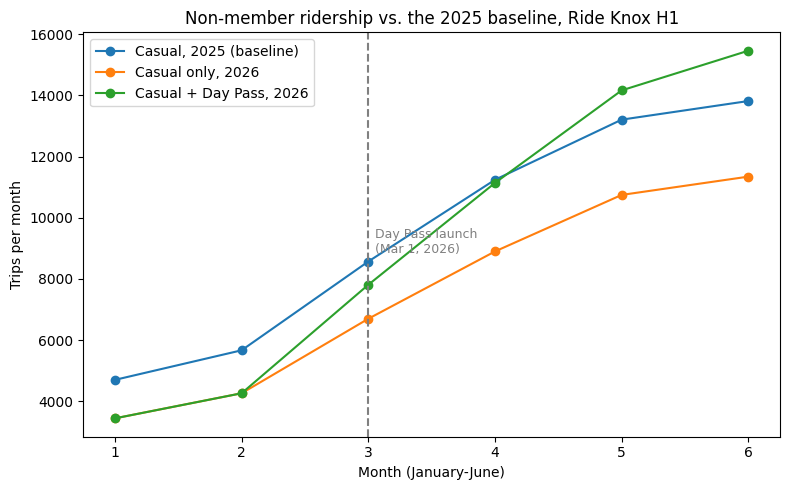

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
months = recovery.index
ax.plot(months, recovery["casual_2025"], marker="o",
        label="Casual, 2025 (baseline)")
ax.plot(months, recovery["casual_2026"], marker="o",
        label="Casual only, 2026")
ax.plot(months, recovery["casual_2026"] + recovery["day_pass_2026"],
        marker="o", label="Casual + Day Pass, 2026")
ax.axvline(3, linestyle="--", color="gray")
ax.text(3.05, ax.get_ylim()[1] * 0.55, "Day Pass launch\n(Mar 1, 2026)",
        fontsize=9, color="gray")
ax.set_xlabel("Month (January-June)")
ax.set_ylabel("Trips per month")
ax.set_title("Non-member ridership vs. the 2025 baseline, Ride Knox H1")
ax.legend()
fig.tight_layout()
fig.savefig("charts/recovery_vs_2025.png", dpi=150)
plt.show()


**Reading.** Casual-only ridership never recovers (still -18% YoY in June).
But casual **plus** day pass crosses the 2025 baseline in **May (+7.2%)** and
reaches **+11.9% in June**, while member trips grow ~+10% every month
regardless. The verdict on "did it work?" depends on whether day-pass riders
count as recovered non-members - a definition, not a computation, so it is
reported both ways.


## Part C - Did the capacity fixes work?

Pressure measure: **starts per dock per operating month**, so stations of
different sizes and different operating periods are comparable. Each year uses
**its own** dock counts (S06/S08 were 24 docks in 2025, 32 in 2026), and S25
is divided by its **4** operating months (opened March 1, 2026).


In [6]:
def pressure(trips, stations, op_months_override=None):
    starts = trips.groupby("start_station_id").size().rename("starts")
    df = stations.set_index("station_id").join(starts)
    df["starts"] = df["starts"].fillna(0)
    df["op_months"] = 6
    if op_months_override:
        for sid, m in op_months_override.items():
            df.loc[sid, "op_months"] = m
    df["per_dock_per_month"] = df["starts"] / df["docks"] / df["op_months"]
    return df["per_dock_per_month"]

capacity = pd.DataFrame({
    "2025": pressure(h1_2025, stations_2025),
    "2026": pressure(trips_2026, stations_2026, {"S25": 4}),
})
capacity["change_%"] = (capacity["2026"] / capacity["2025"] - 1) * 100
focus = capacity.loc[["S06", "S08", "S25", "S23", "S24"]].round(1)
focus.insert(0, "station",
             stations_2026.set_index("station_id")
                          .loc[focus.index, "station_name"])
focus


,station,2025,2026,change_%
station_id,,,,
S06,Hodges Library,94.0,64.6,-31.2
S08,Student Union - UT,90.9,62.4,-31.4
S25,Cumberland Ave & 22nd St,NaN,100.1,NaN
S23,Bearden - Kingston Pike,14.9,31.0,107.5
S24,Sequoyah Hills Park,16.4,16.4,0.1


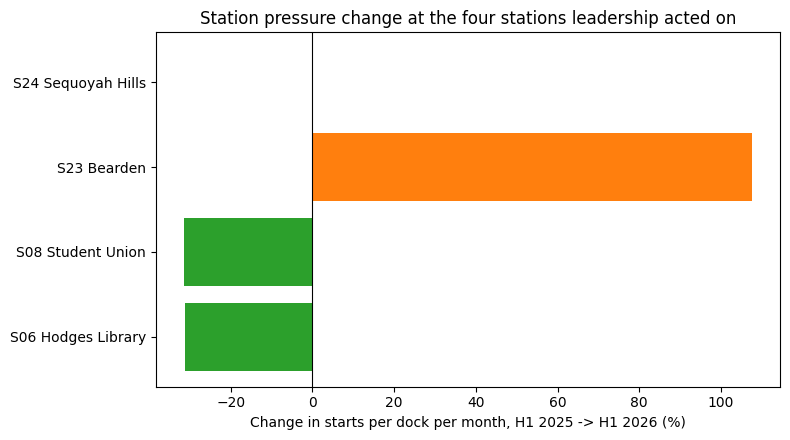

S25 Cumberland Ave & 22nd St, first 4 months: 100.1 starts per dock per month (3rd highest system-wide)


In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
labels = ["S06 Hodges Library", "S08 Student Union",
          "S23 Bearden", "S24 Sequoyah Hills"]
vals = capacity.loc[["S06", "S08", "S23", "S24"], "change_%"]
colors = ["tab:green" if v < 0 else "tab:orange" for v in vals]
ax.barh(labels, vals, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Change in starts per dock per month, H1 2025 -> H1 2026 (%)")
ax.set_title("Station pressure change at the four stations leadership acted on")
fig.tight_layout()
fig.savefig("charts/station_pressure_change.png", dpi=150)
plt.show()

print("S25 Cumberland Ave & 22nd St, first 4 months:",
      round(capacity.loc['S25', '2026'], 1),
      "starts per dock per month (3rd highest system-wide)")


**Reading.** The expansion + new station worked: **S06 and S08 pressure fell
~31%** while untouched stations drifted only 0-7%. **S25 debuted at ~100
starts per dock per month** - instantly top-3 - validating the 2025 siting
recommendation. The 2025 rookies split: **Bearden (S23) doubled (+107%) -
keep**; **Sequoyah Hills (S24) is flat at the system low (16.4) - relocation
candidate.**


## Part D - Who are the day-pass riders?

Groups differ ~7:1 in size, so the comparison uses medians and shares, never
raw counts.


In [8]:
profile = trips_2026.groupby("rider_type").agg(
    trips=("trip_id", "size"),
    median_duration_min=("duration_min", "median"),
    weekend_share=("is_weekend", "mean"),
)
profile["weekend_share_%"] = (profile["weekend_share"] * 100).round(1)
profile["electric_share_%"] = (
    trips_2026.groupby("rider_type")["bike_type"]
              .apply(lambda s: (s == "electric").mean() * 100).round(1))
profile = profile.drop(columns="weekend_share").round(1)
profile


,trips,median_duration_min,weekend_share_%,electric_share_%
rider_type,,,,
casual,45387,19.0,28.9,38.8
day_pass,10886,20.5,61.3,38.2
member,80138,11.6,28.7,37.8


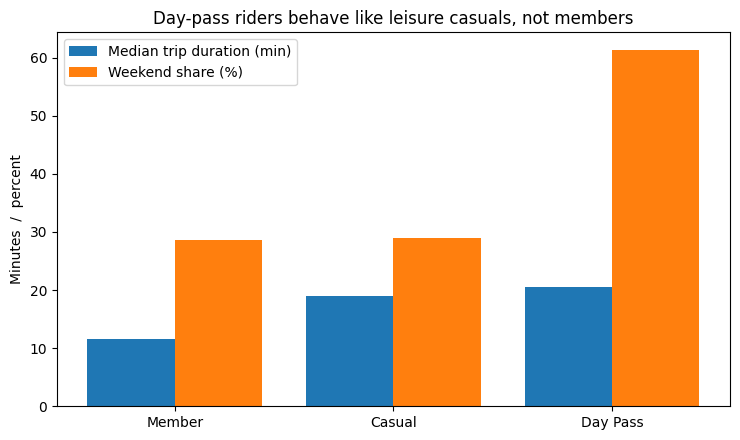

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
groups = ["member", "casual", "day_pass"]
x = range(len(groups))
ax.bar([i - 0.2 for i in x],
       profile.loc[groups, "median_duration_min"], width=0.4,
       label="Median trip duration (min)")
ax.bar([i + 0.2 for i in x],
       profile.loc[groups, "weekend_share_%"], width=0.4,
       label="Weekend share (%)")
ax.set_xticks(list(x))
ax.set_xticklabels(["Member", "Casual", "Day Pass"])
ax.set_title("Day-pass riders behave like leisure casuals, not members")
ax.set_ylabel("Minutes  /  percent")
ax.legend()
fig.tight_layout()
fig.savefig("charts/daypass_vs_others.png", dpi=150)
plt.show()


**Reading.** Day-pass trips run a median **20.5 min** (casual: 19.0; member:
11.6) and **61% happen on weekends** (both other groups: ~29%). Day-pass
riders look like the leisure casuals Ride Knox lost - even more
weekend-tilted - and member growth is undisturbed. This is consistent with
**recovery of a lost segment, not cannibalization of memberships**.

## Limitations

1. Six months of 2026 data; the fall - where the 2025 collapse deepened - is
   unobserved.
2. Observational comparison: spring 2026 weather, novelty effects, and
   marketing are all uncontrolled, so "the Day Pass caused the recovery" is an
   interpretation, not a demonstrated fact.
3. ~800 January-February 2026 trips are missing `end_time` (app bug); they are
   counted but excluded from duration figures, so early-2026 duration
   statistics rest on slightly fewer rows.
4. The recovery verdict is definition-dependent (casual vs. casual+day-pass);
   both definitions are reported above.
